# TrajGPT Population Inference Demo (eICU, Respiratory/Infectious)

This notebook builds a light end-to-end framework using the existing TrajGPT code in this workspace:

1. Build patient trajectories from `eicu_data/diagnosis.csv.gz`.
2. Run short pretraining + few-shot adaptation on a target disease.
3. Produce **individual next-event probabilities**.
4. Aggregate those probabilities into a **population-level prevalence curve**.

Notes:
- `measles` is supported as a target if present in your data.
- In this eICU subset, measles is usually absent; the notebook automatically falls back to `pneumonia`.


## 0) Imports and environment checks


In [70]:
import re
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score


import torch
from torch.utils.data import Dataset, DataLoader

from models.TrajGPT import TrajGPT
from layers.configs import TrajGPTConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cpu"


## 1) Experiment configuration


In [81]:
CFG = {
    # Data
    "diag_path": "eicu_data/diagnosis.csv.gz",
    "max_len": 48,
    "min_events_per_patient": 6,

    # Training (lightweight defaults)
    "batch_size": 32,
    "base_epochs": 10,
    "few_shot_epochs": 10,
    "n_few_shot_patients": 40,
    "learning_rate": 3e-4,

    # Model size (small for quick demo)
    "num_layers": 4,
    "num_heads": 16,
    "d_model": 64,
    "qk_dim": 64,
    "v_dim": 64,
    "tau": 20,
    "ffn_proj_size": 256,
    "dropout": 0.1,

    # Inference aggregation
    "min_context_events": 3,
    "max_windows_per_patient": 4,
    "time_bin_hours": 12,
}

TARGET_DISEASE = "pneumonia"

print("Target disease request:", TARGET_DISEASE)


Target disease request: pneumonia


## 2) Build respiratory/infectious trajectories from eICU

We map diagnosis text to a compact token space (PheCode-like IDs) so it can be fed into TrajGPT's existing pretraining objective.


In [82]:
# Ordered rules: first match wins.
DISEASE_PATTERNS = {
    "measles": [r"\bmeasles\b"],
    "pneumonia": [r"\bpneumonia\b"],
    "sepsis": [r"\bsepsis\b", r"\bsirs\b", r"septic"],
    "resp_failure": [
        r"respiratory failure",
        r"respiratory distress",
        r"hypoxemia",
        r"hypercarbia",
        r"\bards\b",
        r"failure to wean",
    ],
    "asthma_bronchospasm": [r"asthma", r"bronchospasm", r"bronchitis", r"emphysema"],
    "influenza_viral": [r"influenza", r"viral"],
}

GENERAL_RESP_INF_PATTERNS = [r"respiratory", r"pulmonary", r"infectious diseases"]

TOKEN_IDS = {
    "measles": 2101,
    "pneumonia": 2102,
    "sepsis": 2103,
    "resp_failure": 2104,
    "asthma_bronchospasm": 2105,
    "influenza_viral": 2106,
    "resp_infect_other": 2199,
}


def map_diagnosis_to_label(text: str):
    if not isinstance(text, str):
        return None
    t = text.lower()
    for label, patterns in DISEASE_PATTERNS.items():
        if any(re.search(p, t) for p in patterns):
            return label
    if any(re.search(p, t) for p in GENERAL_RESP_INF_PATTERNS):
        return "resp_infect_other"
    return None


def load_eicu_event_frame(diag_path: str, min_events_per_patient: int):
    df = pd.read_csv(
        diag_path,
        compression="gzip",
        usecols=["patientunitstayid", "diagnosisoffset", "diagnosisstring"],
    )
    df["label"] = df["diagnosisstring"].map(map_diagnosis_to_label)
    df = df.dropna(subset=["label"]).copy()
    df["PheCode"] = df["label"].map(TOKEN_IDS).astype(int)

    df = df.rename(columns={"patientunitstayid": "id"})
    df = df.sort_values(["id", "diagnosisoffset"])

    # Normalize each patient timeline to hours since first captured event.
    df["age_at_diag"] = (
        df.groupby("id")["diagnosisoffset"]
        .transform(lambda s: ((s - s.min()).clip(lower=0) / 60.0).round().astype(int))
    )

    base_date = pd.Timestamp("2000-01-01")
    df["date"] = base_date + pd.to_timedelta(df["age_at_diag"], unit="h")
    df["month_of_birth"] = "1900-01-01"

    counts = df.groupby("id").size()
    keep_ids = counts[counts >= min_events_per_patient].index
    df = df[df["id"].isin(keep_ids)].copy()

    cols = ["id", "date", "PheCode", "month_of_birth", "age_at_diag", "label", "diagnosisstring"]
    return df[cols]


events_df = load_eicu_event_frame(CFG["diag_path"], CFG["min_events_per_patient"])
print("Rows:", len(events_df))
print("Patients:", events_df["id"].nunique())
print("Label counts:\n", events_df["label"].value_counts())


Rows: 5924
Patients: 328
Label counts:
 label
resp_failure           1889
resp_infect_other      1834
sepsis                 1258
pneumonia               809
asthma_bronchospasm      87
influenza_viral          47
Name: count, dtype: int64


In [83]:
# Target selection with fallback (measles may be absent in this subset).
available_labels = set(events_df["label"].unique())
if TARGET_DISEASE in available_labels:
    target_label = TARGET_DISEASE
else:
    target_label = FALLBACK_TARGET
    print(f"'{TARGET_DISEASE}' not found in local eICU slice; using fallback target '{target_label}'.")

target_token = TOKEN_IDS[target_label]
print("Target label:", target_label, "| token:", target_token)

# Patient-level split
patient_ids = np.array(sorted(events_df["id"].unique()))
train_ids, temp_ids = train_test_split(patient_ids, test_size=0.30, random_state=SEED)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=SEED)

train_df = events_df[events_df["id"].isin(train_ids)].copy()
val_df = events_df[events_df["id"].isin(val_ids)].copy()
test_df = events_df[events_df["id"].isin(test_ids)].copy()

print(f"Train patients: {len(train_ids)} | Val patients: {len(val_ids)} | Test patients: {len(test_ids)}")


Target label: pneumonia | token: 2102
Train patients: 229 | Val patients: 49 | Test patients: 50


## 3) Sequence dataset + embedding file required by TrajGPT

`TrajGPT` loads token embeddings from `data/phecode_embeddings.csv`. We create a compact embedding file for the tokens in this demo (random init, fixed during training, matching current model design).


In [84]:
class PatientSequenceDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, max_len: int):
        self.max_len = max_len
        self.metadata = []
        self.tensor_samples = []

        grouped = (
            frame.sort_values(["id", "age_at_diag"])                 .groupby("id")                 .agg({"PheCode": list, "age_at_diag": list})                 .reset_index()
        )

        for _, row in grouped.iterrows():
            pid = int(row["id"])
            tokens = list(row["PheCode"])[-max_len:]
            times = list(row["age_at_diag"])[-max_len:]
            length = len(tokens)

            if length == 0:
                continue

            padded_tokens = tokens + [0] * (max_len - length)
            pad_t = times[-1]
            padded_times = times + [pad_t] * (max_len - length)

            self.metadata.append({
                "id": pid,
                "tokens": tokens,
                "times": times,
                "length": length,
            })
            self.tensor_samples.append((
                torch.tensor(padded_tokens, dtype=torch.long),
                torch.tensor(padded_times, dtype=torch.long),
                torch.tensor(length, dtype=torch.long),
                torch.tensor(pid, dtype=torch.long),
            ))

    def __len__(self):
        return len(self.tensor_samples)

    def __getitem__(self, idx):
        return self.tensor_samples[idx]


def ensure_demo_embedding_file(tokens, d_model, path="data/phecode_embeddings.csv", seed=42):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    required_tokens = sorted({int(t) for t in tokens})

    if path.exists():
        current = pd.read_csv(path, index_col=0)
        try:
            current.index = current.index.astype(int)
        except Exception:
            current.index = pd.Index([int(float(x)) for x in current.index])

        same_dim = (current.shape[1] == d_model)
        has_all_tokens = set(required_tokens).issubset(set(current.index.tolist()))

        if same_dim and has_all_tokens:
            print("Embedding file reused:", path)
            return path

        backup = path.with_name(f"{path.stem}.backup_{int(time.time())}{path.suffix}")
        path.rename(backup)
        print("Existing embedding file backed up to:", backup)

    rng = np.random.default_rng(seed)
    emb = rng.normal(0.0, 0.02, size=(len(required_tokens), d_model)).astype(np.float32)
    emb_df = pd.DataFrame(emb, index=required_tokens, columns=[str(i) for i in range(d_model)])
    emb_df.to_csv(path)
    print("Embedding file created:", path, "shape:", emb_df.shape)
    return path


train_ds = PatientSequenceDataset(train_df, CFG["max_len"])
val_ds = PatientSequenceDataset(val_df, CFG["max_len"])
test_ds = PatientSequenceDataset(test_df, CFG["max_len"])

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False)

demo_tokens = events_df["PheCode"].unique().tolist()
_ = ensure_demo_embedding_file(demo_tokens, CFG["d_model"], path="data/phecode_embeddings.csv", seed=SEED)

print("Train sequences:", len(train_ds), "| Val sequences:", len(val_ds), "| Test sequences:", len(test_ds))


Embedding file reused: data/phecode_embeddings.csv
Train sequences: 229 | Val sequences: 49 | Test sequences: 50


## 4) Build TrajGPT and run short base + few-shot training


In [85]:
trajgpt_cfg = TrajGPTConfig(
    num_layers=CFG["num_layers"],
    num_heads=CFG["num_heads"],
    d_model=CFG["d_model"],
    qk_dim=CFG["qk_dim"],
    v_dim=CFG["v_dim"],
    tau=CFG["tau"],
    ffn_proj_size=CFG["ffn_proj_size"],
    use_bias_in_sra=False,
    use_bias_in_mlp=True,
    use_bias_in_sra_out=False,
    use_default_gamma=False,
    forward_impl="parallel",
)
# TrajGPT currently expects these runtime attrs in addition to TrajGPTConfig fields.
trajgpt_cfg.dropout = CFG["dropout"]
trajgpt_cfg.use_grad_ckp = False

model = TrajGPT(configs=trajgpt_cfg, head_type="pretrain").to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG["learning_rate"])


def run_training_phase(model, loader, optimizer, epochs, phase_name):
    if len(loader) == 0:
        print(f"{phase_name}: skipped (empty loader)")
        return []

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for batch_x, batch_t, batch_len, _ in loader:
            batch_x = batch_x.to(DEVICE)
            batch_t = batch_t.to(DEVICE)

            optimizer.zero_grad()
            loss = model(X=batch_x, input_time=batch_t, y=batch_x, forward_impl="parallel")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            losses.append(float(loss.item()))

        epoch_loss = float(np.mean(losses)) if losses else float("nan")
        history.append(epoch_loss)
        print(f"{phase_name} | epoch {epoch}/{epochs} | loss={epoch_loss:.4f}")

    return history


# Base pretraining on all respiratory/infectious trajectories
base_history = run_training_phase(model, train_loader, optimizer, CFG["base_epochs"], "base")

# Few-shot adaptation on a small target-positive patient subset
target_pos_train_ids = (
    train_df.loc[train_df["PheCode"].eq(target_token), "id"]
    .drop_duplicates()
    .tolist()
)
few_ids = target_pos_train_ids[: CFG["n_few_shot_patients"]]
few_df = train_df[train_df["id"].isin(few_ids)].copy()
few_ds = PatientSequenceDataset(few_df, CFG["max_len"])
if len(few_ds) > 0:
    few_loader = DataLoader(
        few_ds,
        batch_size=min(CFG["batch_size"], len(few_ds)),
        shuffle=True,
    )
else:
    few_loader = []

print("Few-shot patients:", len(few_ids), "| sequences:", len(few_ds))
few_history = run_training_phase(model, few_loader, optimizer, CFG["few_shot_epochs"], "few-shot")


base | epoch 1/10 | loss=1.8271
base | epoch 2/10 | loss=1.3855
base | epoch 3/10 | loss=1.2345
base | epoch 4/10 | loss=1.1590
base | epoch 5/10 | loss=1.1259
base | epoch 6/10 | loss=1.1303
base | epoch 7/10 | loss=1.0495
base | epoch 8/10 | loss=1.0282
base | epoch 9/10 | loss=1.0845
base | epoch 10/10 | loss=1.0204
Few-shot patients: 40 | sequences: 40
few-shot | epoch 1/10 | loss=1.1917
few-shot | epoch 2/10 | loss=1.1647
few-shot | epoch 3/10 | loss=1.1304
few-shot | epoch 4/10 | loss=1.0598
few-shot | epoch 5/10 | loss=1.0215
few-shot | epoch 6/10 | loss=0.9936
few-shot | epoch 7/10 | loss=0.9035
few-shot | epoch 8/10 | loss=0.8676
few-shot | epoch 9/10 | loss=0.8288
few-shot | epoch 10/10 | loss=0.8044


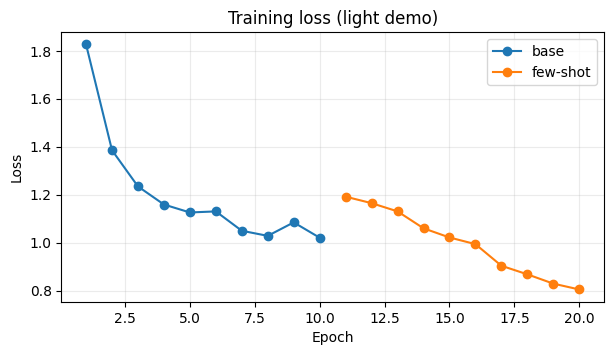

In [86]:
plt.figure(figsize=(7, 3.5))
if base_history:
    plt.plot(range(1, len(base_history) + 1), base_history, marker="o", label="base")
if few_history:
    x0 = len(base_history)
    plt.plot(range(x0 + 1, x0 + len(few_history) + 1), few_history, marker="o", label="few-shot")
plt.title("Training loss (light demo)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## 5) Individual forecasting helper (next-event target probability)

The current `TrajGPT.forward()` returns loss. For inference, we reuse internal blocks to extract logits and compute `P(next_event = target_disease)` for each patient prefix.


In [87]:
@torch.no_grad()
def forward_logits(model, batch_x, batch_t, retention_mask=None):
    model.eval()
    B, T = batch_x.shape

    hidden_states = torch.zeros(B, T, model.d_model, device=batch_x.device)
    for i in range(B):
        hidden_states[i] = model.token_embedding(batch_x[i])

    sos_token = model.sos.unsqueeze(0).repeat(B, 1, 1)
    hidden_states = torch.cat([sos_token, hidden_states[:, :-1, :]], dim=1)

    if retention_mask is None:
        retention_mask = batch_x.ne(0)

    for block in model.SRA_blocks:
        block_out = block(
            hidden_states,
            t=batch_t,
            retention_mask=retention_mask,
            forward_impl="parallel",
            output_retentions=False,
        )
        hidden_states = block_out[0]

    outputs = model.ln_f(hidden_states)
    logits = model.head(outputs)
    return logits


def build_prefix_windows(sequence_dataset, target_token, min_context, max_windows_per_patient, max_len):
    records = []
    for meta in sequence_dataset.metadata:
        tokens = meta["tokens"]
        times = meta["times"]
        pid = meta["id"]
        L = meta["length"]

        if L <= min_context:
            continue

        possible_positions = np.arange(min_context - 1, L - 1)  # position p predicts token at p+1
        if len(possible_positions) == 0:
            continue

        if len(possible_positions) > max_windows_per_patient:
            sel_idx = np.linspace(0, len(possible_positions) - 1, num=max_windows_per_patient, dtype=int)
            positions = possible_positions[sel_idx]
        else:
            positions = possible_positions

        for pos in positions:
            prefix_len = int(pos + 1)

            px = np.zeros(max_len, dtype=np.int64)
            pt = np.zeros(max_len, dtype=np.int64)
            px[:prefix_len] = np.asarray(tokens[:prefix_len], dtype=np.int64)
            pt[:prefix_len] = np.asarray(times[:prefix_len], dtype=np.int64)
            pt[prefix_len:] = times[prefix_len - 1]

            actual_next = int(tokens[pos + 1] == target_token)
            current_time = int(times[pos])

            records.append({
                "id": pid,
                "x": px,
                "t": pt,
                "prefix_len": prefix_len,
                "current_time_hours": current_time,
                "actual_next": actual_next,
            })

    return pd.DataFrame(records)


class PrefixWindowDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        return (
            torch.tensor(row["x"], dtype=torch.long),
            torch.tensor(row["t"], dtype=torch.long),
            torch.tensor(int(row["prefix_len"]), dtype=torch.long),
            torch.tensor(int(row["current_time_hours"]), dtype=torch.long),
            torch.tensor(int(row["actual_next"]), dtype=torch.long),
            torch.tensor(int(row["id"]), dtype=torch.long),
        )


prefix_frame = build_prefix_windows(
    test_ds,
    target_token=target_token,
    min_context=CFG["min_context_events"],
    max_windows_per_patient=CFG["max_windows_per_patient"],
    max_len=CFG["max_len"],
)
print("Prefix windows in test set:", len(prefix_frame))
prefix_frame.head()


Prefix windows in test set: 192


,id,x,t,prefix_len,current_time_hours,actual_next
0,209139,"[2104, 2199, 2104, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,0,0
1,209139,"[2104, 2199, 2104, 2103, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...",4,3,0
2,209139,"[2104, 2199, 2104, 2103, 2104, 0, 0, 0, 0, 0, ...","[0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...",5,3,0
3,209139,"[2104, 2199, 2104, 2103, 2104, 2104, 0, 0, 0, ...","[0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...",6,3,0
4,261520,"[2104, 2104, 2104, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 7, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19,...",3,19,0


In [88]:
if len(prefix_frame) == 0:
    raise RuntimeError("No prefix windows available. Lower min_context_events or min_events_per_patient.")

prefix_ds = PrefixWindowDataset(prefix_frame)
prefix_loader = DataLoader(prefix_ds, batch_size=CFG["batch_size"], shuffle=False)

target_index = model.token_embedding.phecode_to_index.get(int(target_token), None)
if target_index is None:
    raise RuntimeError(f"Target token {target_token} not found in model embedding mapping.")

rows = []
for x, t, prefix_len, current_time, actual_next, pid in prefix_loader:
    x = x.to(DEVICE)
    t = t.to(DEVICE)
    prefix_len = prefix_len.to(DEVICE)

    logits = forward_logits(model, x, t)
    probs = torch.softmax(logits, dim=-1)

    pos = (prefix_len - 1).long()
    b_idx = torch.arange(x.size(0), device=DEVICE)
    pred_prob = probs[b_idx, pos, target_index]

    rows.extend(
        {
            "id": int(pid_i.item()),
            "current_time_hours": int(ct.item()),
            "actual_next": int(y.item()),
            "pred_prob": float(p.item()),
        }
        for pid_i, ct, y, p in zip(pid.cpu(), current_time.cpu(), actual_next.cpu(), pred_prob.cpu())
    )

pred_df = pd.DataFrame(rows)
pred_df["time_bin"] = (pred_df["current_time_hours"] // CFG["time_bin_hours"]).astype(int)
pred_df.head()


,id,current_time_hours,actual_next,pred_prob,time_bin
0,209139,0,0,0.477049,0
1,209139,3,0,0.390343,0
2,209139,3,0,0.589546,0
3,209139,3,0,0.228104,0
4,261520,19,0,0.218817,1


## 6) Population-level inference from individual forecasts

We estimate population prevalence by averaging individual target-event probabilities inside each time bin.


In [89]:
pop_df = (
    pred_df.groupby("time_bin", as_index=False)
    .agg(
        pred_prevalence=("pred_prob", "mean"),
        obs_prevalence=("actual_next", "mean"),
        pred_cases=("pred_prob", "sum"),
        obs_cases=("actual_next", "sum"),
        n_windows=("actual_next", "size"),
    )
    .sort_values("time_bin")
)

# quick quality metrics on individual windows
if pred_df["actual_next"].nunique() > 1:
    roc_auc = roc_auc_score(pred_df["actual_next"], pred_df["pred_prob"])
    pr_auc = average_precision_score(pred_df["actual_next"], pred_df["pred_prob"])
    print(f"Individual-level ROC-AUC: {roc_auc:.3f} | PR-AUC: {pr_auc:.3f}")
else:
    print("Only one class present in actual_next; ROC-AUC/PR-AUC are undefined for this slice.")

pop_df.head(20)


Individual-level ROC-AUC: 0.621 | PR-AUC: 0.335


,time_bin,pred_prevalence,obs_prevalence,pred_cases,obs_cases,n_windows
0,0,0.204237,0.123288,14.909293,9,73
1,1,0.255424,0.142857,7.151881,4,28
2,2,0.235564,0.277778,4.240157,5,18
3,3,0.109563,0.208333,2.629522,5,24
4,4,0.177054,0.000000,1.416432,0,8
5,5,0.158605,0.100000,1.586051,1,10
6,6,0.083056,0.000000,0.166112,0,2
7,7,0.180948,0.000000,0.723794,0,4
8,8,0.198818,0.000000,0.198818,0,1
9,9,0.187530,0.000000,0.750120,0,4


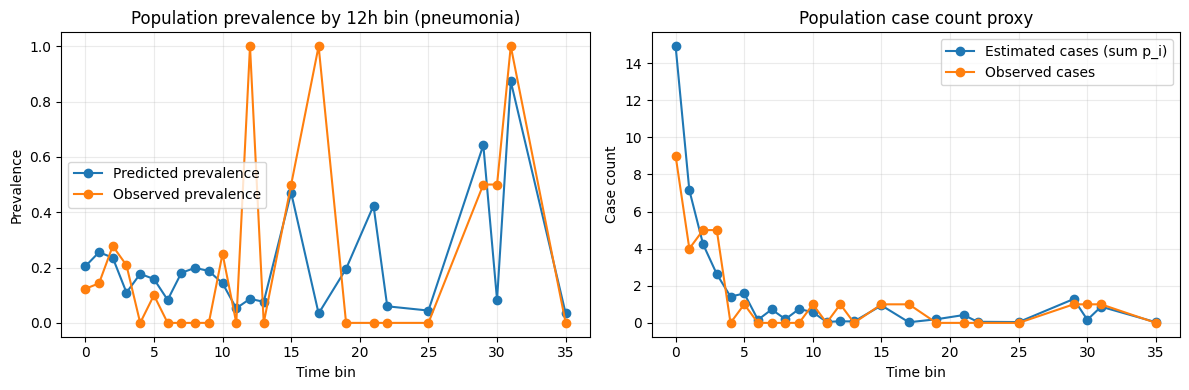

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(pop_df["time_bin"], pop_df["pred_prevalence"], marker="o", label="Predicted prevalence")
axes[0].plot(pop_df["time_bin"], pop_df["obs_prevalence"], marker="o", label="Observed prevalence")
axes[0].set_title(f"Population prevalence by {CFG['time_bin_hours']}h bin ({target_label})")
axes[0].set_xlabel("Time bin")
axes[0].set_ylabel("Prevalence")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(pop_df["time_bin"], pop_df["pred_cases"], marker="o", label="Estimated cases (sum p_i)")
axes[1].plot(pop_df["time_bin"], pop_df["obs_cases"], marker="o", label="Observed cases")
axes[1].set_title("Population case count proxy")
axes[1].set_xlabel("Time bin")
axes[1].set_ylabel("Case count")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()
